In [37]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.impute import IterativeImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [38]:
data = sm.datasets.get_rdataset('mtcars').data

In [71]:
data.head(10)

,car_model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_kmpl,mpg_std,hp_norm
0,Mazda RX4,21.0,6,160.0,110.000000,3.90,2.620,16.46,0,1,4,4,8.928024,0.146171,0.204947
1,Mazda RX4 Wag,21.0,6,160.0,110.000000,3.90,2.875,17.02,0,1,4,4,8.928024,0.146171,0.204947
2,Datsun 710,22.8,4,108.0,93.000000,3.85,2.320,18.61,1,1,4,1,9.693283,0.444938,0.144876
3,Hornet 4 Drive,21.4,6,258.0,110.000000,3.08,3.215,19.44,1,0,3,1,9.098082,0.212564,0.204947
4,Hornet Sportabout,18.7,8,360.0,145.774194,3.15,3.440,17.02,0,0,3,2,7.950193,-0.235587,0.331358
5,Valiant,18.1,6,225.0,105.000000,2.76,3.460,20.22,1,0,3,1,7.695106,-0.335176,0.187279
6,Duster 360,14.3,8,360.0,245.000000,3.21,3.570,15.84,0,0,3,4,6.079559,-0.965907,0.681979
7,Merc 240D,24.4,4,146.7,62.000000,3.69,3.190,20.00,1,0,4,2,10.373514,0.710509,0.035336
8,Merc 230,22.8,4,140.8,95.000000,3.92,3.150,22.90,1,0,4,2,9.693283,0.444938,0.151943
9,Merc 280,NaN,6,167.6,123.000000,3.92,3.440,18.30,1,0,4,4,NaN,NaN,0.250883


In [40]:
# Answer 1: 
# Dimensions
data.shape

(32, 11)

In [ ]:
# Answer 2: 
# Each row represents one car model (observation). It shows the measurements and features recorded for that specific car.

In [42]:
# Answer 3: 
# Numeric variables
# mpg = miles per gallon
# hp  = horsepower
# wt  = weight
# cyl = number of cylinders
# disp = engine displacement

In [43]:
# Answer 4:
# Quick summary
data.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [ ]:
# Answer 5:
# Missing values check
# No, the original dataset does not contain missing values.
data.isna().sum()

mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

In [45]:
# Answer 6:
# Clean column names
data.columns = data.columns.str.lower().str.replace(" ", "_")
data.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear',
       'carb'],
      dtype='object')

In [46]:
# Answer 7:
# Add missing values
data.loc[data.index[4], 'hp'] = np.nan
data.loc[data.index[9], 'mpg'] = np.nan
data.head(10)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110.0,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110.0,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93.0,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110.0,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,NaN,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105.0,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245.0,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62.0,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95.0,3.92,3.150,22.90,1,0,4,2


In [ ]:
# Answer 8:
# Remove rows with missing values
# Rows with missing values can be removed using a 'dropna()' method.
data_no_na = data.dropna()
data_no_na.isna().sum()


mpg     0
cyl     0
disp    0
hp      0
drat    0
wt      0
qsec    0
vs      0
am      0
gear    0
carb    0
dtype: int64

In [48]:
# Answer 9:
# Replace missng hp with mean
data['hp'] = data['hp'].fillna(data['hp'].mean())

In [ ]:
# Answer 10:
# MICE imputation: MICE imputation fills in missing values using patterns from other variables in the dataset. It predicts missing values instead of just deleting rows.
imputer = IterativeImputer(random_state=0)
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

In [50]:
data_imputed.head(10)

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,21.00000,6.0,160.0,110.000000,3.90,2.620,16.46,0.0,1.0,4.0,4.0
1,21.00000,6.0,160.0,110.000000,3.90,2.875,17.02,0.0,1.0,4.0,4.0
2,22.80000,4.0,108.0,93.000000,3.85,2.320,18.61,1.0,1.0,4.0,1.0
3,21.40000,6.0,258.0,110.000000,3.08,3.215,19.44,1.0,0.0,3.0,1.0
4,18.70000,8.0,360.0,145.774194,3.15,3.440,17.02,0.0,0.0,3.0,2.0
5,18.10000,6.0,225.0,105.000000,2.76,3.460,20.22,1.0,0.0,3.0,1.0
6,14.30000,8.0,360.0,245.000000,3.21,3.570,15.84,0.0,0.0,3.0,4.0
7,24.40000,4.0,146.7,62.000000,3.69,3.190,20.00,1.0,0.0,4.0,2.0
8,22.80000,4.0,140.8,95.000000,3.92,3.150,22.90,1.0,0.0,4.0,2.0
9,22.67695,6.0,167.6,123.000000,3.92,3.440,18.30,1.0,0.0,4.0,4.0


In [51]:
# Answer 11:
# Q1, Q3, IQR for hp
Q1 = data['hp'].quantile(0.25)
Q3 = data['hp'].quantile(0.75)
IQR_value = Q3-Q1

In [52]:
print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR Value: {IQR_value}')

Q1: 96.5
Q3: 180.0
IQR Value: 83.5


In [53]:
# Answer 12:
# Outlier bounds
lower_bound = Q1 - 1.5 * IQR_value
upper_bound = Q3 + 1.5 * IQR_value
print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')


Lower Bound: -28.75
Upper Bound: 305.25


In [54]:
# Answer 13:
# Indentify outliers
outliers = data[(data["hp"] < lower_bound) | (data["hp"] > upper_bound)]
outliers

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
rownames,,,,,,,,,,,
Maserati Bora,15.0,8,301.0,335.0,3.54,3.57,14.6,0,1,5,8


In [55]:
# Answer 14:
# Capping is when very high or very low values are replaced with fixed limits instead of being removed, so all data is kept but extreme values have less effect.

In [56]:
# Answer 15:
# Convert mpg to kilometers per liter
data["mpg_kmpl"] = data["mpg"] * 0.425144
data.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_kmpl
rownames,,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110.000000,3.90,2.620,16.46,0,1,4,4,8.928024
Mazda RX4 Wag,21.0,6,160.0,110.000000,3.90,2.875,17.02,0,1,4,4,8.928024
Datsun 710,22.8,4,108.0,93.000000,3.85,2.320,18.61,1,1,4,1,9.693283
Hornet 4 Drive,21.4,6,258.0,110.000000,3.08,3.215,19.44,1,0,3,1,9.098082
Hornet Sportabout,18.7,8,360.0,145.774194,3.15,3.440,17.02,0,0,3,2,7.950193


In [ ]:
# Answer 16:
# Unit conversion is a simple form of feature engineering because it involves transforming an existing variable into a new, more useful representation without changing the underlying information.

In [58]:
# Answer 17:
# Standardize mpg
scaler = StandardScaler()
data['mpg_std'] = scaler.fit_transform(data[['mpg']])
data.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_kmpl,mpg_std
rownames,,,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110.000000,3.90,2.620,16.46,0,1,4,4,8.928024,0.146171
Mazda RX4 Wag,21.0,6,160.0,110.000000,3.90,2.875,17.02,0,1,4,4,8.928024,0.146171
Datsun 710,22.8,4,108.0,93.000000,3.85,2.320,18.61,1,1,4,1,9.693283,0.444938
Hornet 4 Drive,21.4,6,258.0,110.000000,3.08,3.215,19.44,1,0,3,1,9.098082,0.212564
Hornet Sportabout,18.7,8,360.0,145.774194,3.15,3.440,17.02,0,0,3,2,7.950193,-0.235587


In [59]:
# Answer 18:
# Normalize hp (min-max)
minmax = MinMaxScaler()
data['hp_norm'] = minmax.fit_transform(data[['hp']])
data.head()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_kmpl,mpg_std,hp_norm
rownames,,,,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110.000000,3.90,2.620,16.46,0,1,4,4,8.928024,0.146171,0.204947
Mazda RX4 Wag,21.0,6,160.0,110.000000,3.90,2.875,17.02,0,1,4,4,8.928024,0.146171,0.204947
Datsun 710,22.8,4,108.0,93.000000,3.85,2.320,18.61,1,1,4,1,9.693283,0.444938,0.144876
Hornet 4 Drive,21.4,6,258.0,110.000000,3.08,3.215,19.44,1,0,3,1,9.098082,0.212564,0.204947
Hornet Sportabout,18.7,8,360.0,145.774194,3.15,3.440,17.02,0,0,3,2,7.950193,-0.235587,0.331358


In [60]:
# Answer 19:
# Create second dataset (car names + category)
car_names = data.index.tolist()

categories = ["Sedan", "Sports", "SUV"] * (len(car_names) // 3 + 1)

data2 = pd.DataFrame({
    "car_model": car_names,
    "category": categories[:len(car_names)]
})

data2.head()

,car_model,category
0,Mazda RX4,Sedan
1,Mazda RX4 Wag,Sports
2,Datsun 710,SUV
3,Hornet 4 Drive,Sedan
4,Hornet Sportabout,Sports


In [ ]:
# Answer 20
# A left join can be used to merge the second dataset with the original dataset. A left join keeps all rows from the main dataset and adds matching values from the second dataset.
# Merge datasets (left join)
data = data.reset_index().rename(columns={"rownames": "car_model"})
merged_data = pd.merge(data, data2, on="car_model", how="left")
merged_data.head()

,car_model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_kmpl,mpg_std,hp_norm,category
0,Mazda RX4,21.0,6,160.0,110.000000,3.90,2.620,16.46,0,1,4,4,8.928024,0.146171,0.204947,Sedan
1,Mazda RX4 Wag,21.0,6,160.0,110.000000,3.90,2.875,17.02,0,1,4,4,8.928024,0.146171,0.204947,Sports
2,Datsun 710,22.8,4,108.0,93.000000,3.85,2.320,18.61,1,1,4,1,9.693283,0.444938,0.144876,SUV
3,Hornet 4 Drive,21.4,6,258.0,110.000000,3.08,3.215,19.44,1,0,3,1,9.098082,0.212564,0.204947,Sedan
4,Hornet Sportabout,18.7,8,360.0,145.774194,3.15,3.440,17.02,0,0,3,2,7.950193,-0.235587,0.331358,Sports


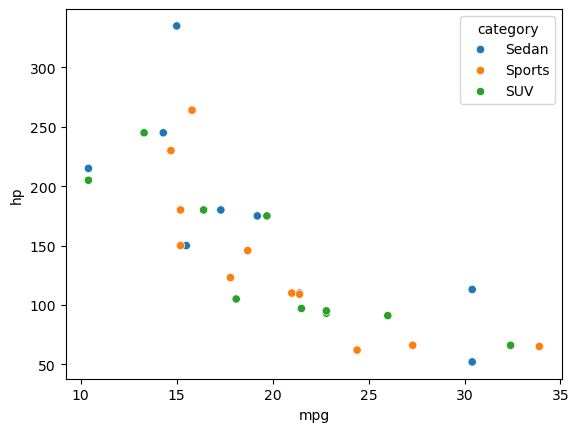

In [62]:
# Answer 21
sns.scatterplot(data=merged_data, x="mpg", y="hp", hue="category")
plt.show()

In [63]:
# Answer 22:
# Cars with higher horsepower generally have lower fuel efficiency (mpg), and cars with lower horsepower tend to have higher mpg. This shows a negative relationship between horsepower and fuel efficiency.

In [64]:
# Answer 23:
merged_data.select_dtypes(include='number').corr()


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_kmpl,mpg_std,hp_norm
mpg,1.000000,-0.853145,-0.854063,-0.778561,0.688606,-0.867603,0.420526,0.684111,0.602732,0.483992,-0.552501,1.000000,1.000000,-0.778561
cyl,-0.853145,1.000000,0.902033,0.820826,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988,-0.853145,-0.853145,0.820826
disp,-0.854063,0.902033,1.000000,0.778820,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977,-0.854063,-0.854063,0.778820
hp,-0.778561,0.820826,0.778820,1.000000,-0.438522,0.657487,-0.703847,-0.713189,-0.232671,-0.113213,0.758887,-0.778561,-0.778561,1.000000
drat,0.688606,-0.699938,-0.710214,-0.438522,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790,0.688606,0.688606,-0.438522
wt,-0.867603,0.782496,0.887980,0.657487,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606,-0.867603,-0.867603,0.657487
qsec,0.420526,-0.591242,-0.433698,-0.703847,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249,0.420526,0.420526,-0.703847
vs,0.684111,-0.810812,-0.710416,-0.713189,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607,0.684111,0.684111,-0.713189
am,0.602732,-0.522607,-0.591227,-0.232671,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534,0.602732,0.602732,-0.232671
gear,0.483992,-0.492687,-0.555569,-0.113213,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073,0.483992,0.483992,-0.113213


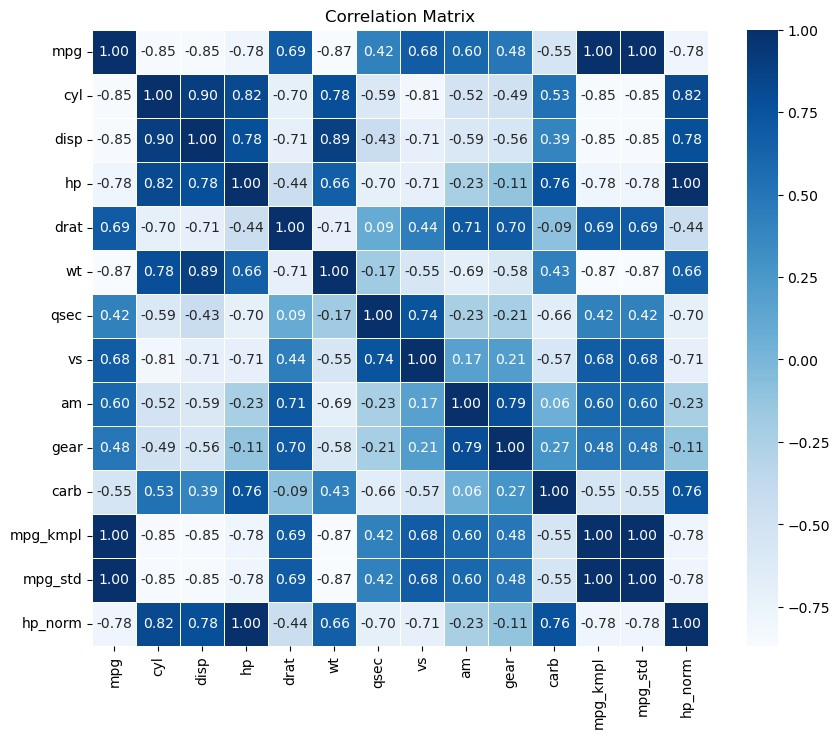

In [ ]:
# Answer 24:
# A heatmap function can be used to visualize the correlation matrix.
plt.figure(figsize=(10, 8))

sns.heatmap(
    merged_data.select_dtypes(include='number').corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix")
plt.show()

In [66]:
# Answer 25:
train, test = train_test_split(merged_data, test_size=0.2, random_state=42)

In [67]:
print(f'Training data shape: {train.shape}')
print(f'Testing data shape: {test.shape}')

Training data shape: (25, 16)
Testing data shape: (7, 16)


In [ ]:
# Answer 26:
# We set a random seed to make the results reproducible. This means the same random sample or split will be generated every time the code is run.

In [69]:
# Answer 27:
merged_data['high_mpg'] = np.where(
    merged_data['mpg'] > merged_data['mpg'].median(),
    "High",
    "Low"
)

merged_data.head()

,car_model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,mpg_kmpl,mpg_std,hp_norm,category,high_mpg
0,Mazda RX4,21.0,6,160.0,110.000000,3.90,2.620,16.46,0,1,4,4,8.928024,0.146171,0.204947,Sedan,High
1,Mazda RX4 Wag,21.0,6,160.0,110.000000,3.90,2.875,17.02,0,1,4,4,8.928024,0.146171,0.204947,Sports,High
2,Datsun 710,22.8,4,108.0,93.000000,3.85,2.320,18.61,1,1,4,1,9.693283,0.444938,0.144876,SUV,High
3,Hornet 4 Drive,21.4,6,258.0,110.000000,3.08,3.215,19.44,1,0,3,1,9.098082,0.212564,0.204947,Sedan,High
4,Hornet Sportabout,18.7,8,360.0,145.774194,3.15,3.440,17.02,0,0,3,2,7.950193,-0.235587,0.331358,Sports,Low


In [ ]:
# Answer 28:
# It converts a continuous variable into a categorical label, which can be used for classification models, easier interpretation, and group-based analysis.